  # 🏦 Credit Scorecard Development Pipeline



  **Goal**: Build a regulatory-grade scorecard with robust calibration.



  **Updated Methodology**:

  1. **Train Set**: Used to fit WoE Bins and train Logistic Regression.

  2. **Validation Set**: Used *only* to fit the Isotonic Calibrator (preventing overfitting).

  3. **Test Set**: Used for final performance evaluation (KS, Gini, Calibration Check).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
sns.set_style("whitegrid")



  ## 1. 🧹 Data Loading & Strict Leakage Cleanup

In [2]:
# Load Data
df = pd.read_csv('C:/Users/hungn/Downloads/ac.gz', compression='gzip', low_memory=False)

# 1. Target Definition
loan_status_mapping = {
    'Fully Paid': 1,            
    'Current': 1,               
    'In Grace Period': 1,       
    'Late (16-30 days)': 0,     
    'Late (31-120 days)': 0,    
    'Charged Off': 0,           
    'Default': 0,
    'Does not meet the credit policy. Status:Fully Paid': 1,
    'Does not meet the credit policy. Status:Charged Off': 0                
}

df['loan_status_binary'] = df['loan_status'].map(loan_status_mapping)
df.dropna(subset=['loan_status_binary'], inplace=True)

# 2. Leakage Cleanup
leakage_cols = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'pymnt_plan',
    'last_fico_range_high', 'last_fico_range_low', 'last_credit_pull_d',
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',
    'loan_status', 'url', 'id', 'member_id'
]

cols_to_drop = [col for col in leakage_cols if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dataset shape after leakage cleanup: {df.shape}")



Dataset shape after leakage cleanup: (2260668, 110)


  ## 2. 🛠️ Feature Engineering

In [3]:
# Date Processing
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df.dropna(subset=['earliest_cr_line', 'issue_d'], inplace=True)

df['credit_hist_months'] = ((df['issue_d'] - df['earliest_cr_line']).dt.days / 30.4375).astype(int)
df.drop(columns=['issue_d', 'earliest_cr_line'], inplace=True)

# Numeric conversions
df['emp_length'] = df['emp_length'].fillna('< 1 year').astype(str)
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').fillna(0).astype(int)

if 'term' in df.columns:
    df['term_int'] = df['term'].str.extract(r'(\d+)').astype(float)
    df.drop('term', axis=1, inplace=True)

# Simple Imputation
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Feature Engineering complete.")



Feature Engineering complete.


  ## 3. ✂️ Train / Validation / Test Split (3-Way Split)

  **New Strategy**:

  * **Train (60%)**: Fit WoE and Logistic Model.

  * **Validation (20%)**: Fit Isotonic Calibrator (unseen data for the model).

  * **Test (20%)**: Final Evaluation.

In [4]:
X = df.drop(['loan_status_binary'], axis=1, errors='ignore')
y = df['loan_status_binary']

# 1. Split out Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Split remaining 80% into Train (75% of temp = 60% total) and Val (25% of temp = 20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train Size: {X_train.shape[0]} (60%)")
print(f"Val Size:   {X_val.shape[0]} (20%)")
print(f"Test Size:  {X_test.shape[0]} (20%)")



Train Size: 1356383 (60%)
Val Size:   452128 (20%)
Test Size:  452128 (20%)


  ## 4. Automated WoE Transformation

In [5]:
class WoE_Binning:
    def __init__(self, max_bins=5, min_samples=0.05):
        self.max_bins = max_bins
        self.min_samples = min_samples
        self.woe_maps = {}
        self.iv_values = {}
        
    def fit(self, X, y):
        for col in X.columns:
            if pd.api.types.is_numeric_dtype(X[col]):
                dt = DecisionTreeClassifier(max_leaf_nodes=self.max_bins, min_samples_leaf=self.min_samples, random_state=42)
                dt.fit(X[[col]], y)
                thresholds = np.sort(dt.tree_.threshold[dt.tree_.threshold != -2])
                bins = [-np.inf] + list(thresholds) + [np.inf]
                self._calculate_woe(X[col], y, col, bins=bins, is_numeric=True)
            else:
                self._calculate_woe(X[col], y, col, is_numeric=False)
                
    def _calculate_woe(self, feature_series, target, col_name, bins=None, is_numeric=True):
        df_temp = pd.DataFrame({'feature': feature_series, 'target': target})
        if is_numeric:
            df_temp['bin'] = pd.cut(df_temp['feature'], bins=bins, duplicates='drop')
        else:
            df_temp['bin'] = df_temp['feature']
            
        grouped = df_temp.groupby('bin', observed=False)['target'].agg(['count', 'sum'])
        grouped['good'] = grouped['sum']
        grouped['bad'] = grouped['count'] - grouped['sum']
        
        total_good = grouped['good'].sum()
        total_bad = grouped['bad'].sum()
        
        grouped['dist_good'] = (grouped['good'] + 0.5) / total_good
        grouped['dist_bad'] = (grouped['bad'] + 0.5) / total_bad
        
        grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad'])
        grouped['iv'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']
        
        self.woe_maps[col_name] = grouped['woe'].to_dict()
        self.iv_values[col_name] = grouped['iv'].sum()
        if is_numeric:
            self.woe_maps[col_name]['bins'] = bins

    def transform(self, X):
        X_woe = X.copy()
        for col in self.woe_maps:
            mapping = self.woe_maps[col]
            if 'bins' in mapping:
                bins = mapping['bins']
                binned_series = pd.cut(X[col], bins=bins, duplicates='drop')
                X_woe[col] = binned_series.map(mapping).astype(float)
            else:
                X_woe[col] = X[col].map(mapping).fillna(0).astype(float)
        return X_woe

# Fit on Train ONLY
woe_encoder = WoE_Binning(max_bins=6, min_samples=0.05)
woe_encoder.fit(X_train, y_train)

# Transform ALL sets
X_train_woe = woe_encoder.transform(X_train)
X_val_woe = woe_encoder.transform(X_val)   # NEW
X_test_woe = woe_encoder.transform(X_test)

print("WoE Transformation complete.")



WoE Transformation complete.


  ## 5. Feature Selection

In [6]:
# IV Filter
iv_df = pd.DataFrame.from_dict(woe_encoder.iv_values, orient='index', columns=['IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
selected_features = iv_df[(iv_df['IV'] >= 0.02) & (iv_df['IV'] <= 0.55)].index.tolist()

# Correlation Filter
def drop_correlated_features(df_woe, iv_df, threshold=0.7):
    corr_matrix = df_woe.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = set()
    for col in upper_tri.columns:
        correlated_cols = upper_tri.index[upper_tri[col] > threshold].tolist()
        for row in correlated_cols:
            iv_col = iv_df.loc[col, 'IV']
            iv_row = iv_df.loc[row, 'IV']
            if iv_col > iv_row:
                to_drop.add(row)
            else:
                to_drop.add(col)
    return list(to_drop)

features_to_drop_corr = drop_correlated_features(X_train_woe[selected_features], iv_df)
final_features = [f for f in selected_features if f not in features_to_drop_corr]

print(f"Final Feature Count: {len(final_features)}")

# Apply to ALL sets
X_train_final = X_train_woe[final_features]
X_val_final = X_val_woe[final_features]   # NEW
X_test_final = X_test_woe[final_features]



Final Feature Count: 33


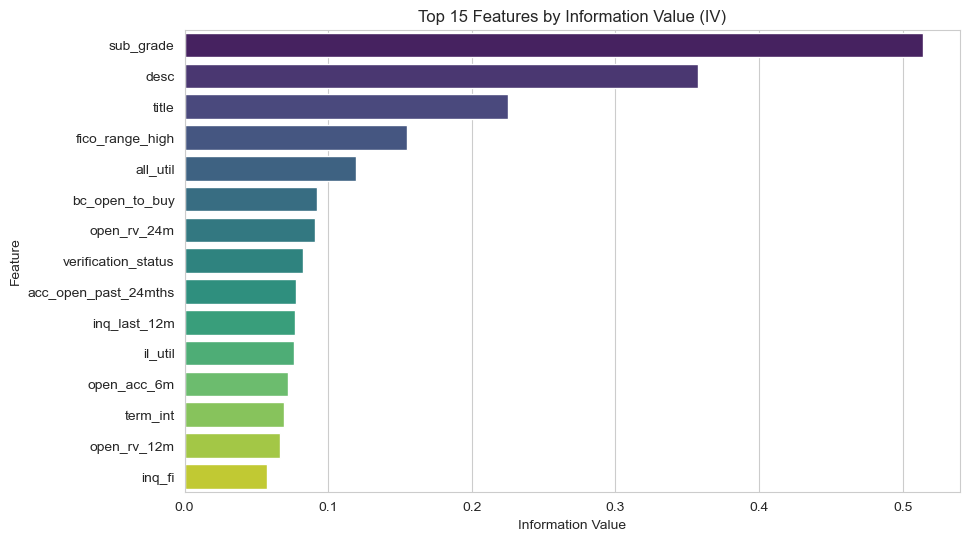

In [7]:
# --- ADDED VISUALIZATION: Top IV Features ---
plt.figure(figsize=(10, 6))
sns.barplot(x='IV', y=iv_df.loc[final_features].head(15).index, data=iv_df.loc[final_features].head(15), palette='viridis')
plt.title('Top 15 Features by Information Value (IV)')
plt.xlabel('Information Value')
plt.ylabel('Feature')
plt.show()

  ## 6. 📉 Logistic Regression Training (On Train)

In [8]:
model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, class_weight='balanced')
model.fit(X_train_final, y_train)

print(f"Intercept: {model.intercept_[0]:.4f}")



Intercept: 0.0775


  ## 7. ⚖️ Calibration (Fit on Validation)

  We use the **Validation Set** to learn the calibration map. This ensures the calibrator doesn't just memorize the training noise.

In [9]:
# 1. Predict Raw Probabilities on Validation Set
y_val_proba = model.predict_proba(X_val_final)[:, 1]

# 2. Fit Isotonic Regression on Validation Data
iso_reg = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
iso_reg.fit(y_val_proba, y_val)

print("Calibrator fitted on Validation Set.")



Calibrator fitted on Validation Set.


  ## 8. 📏 Final Evaluation (On Test)

In [10]:
# 1. Get Raw and Calibrated Probs for Test Set
y_test_raw_proba = model.predict_proba(X_test_final)[:, 1]
y_test_calib_proba = iso_reg.predict(y_test_raw_proba)

# 2. Calculate Metrics on Calibrated Output (or Raw, depending on requirement)
# Note: AUC/Gini/KS are rank-order metrics, so they don't change with monotonic calibration.
auc = roc_auc_score(y_test, y_test_raw_proba)
gini = 2 * auc - 1
fpr, tpr, _ = roc_curve(y_test, y_test_raw_proba)
ks = max(tpr - fpr)

print(f"📊 Test Set Metrics:")
print(f"AUC : {auc:.4f}")
print(f"Gini: {gini:.4f}")
print(f"KS  : {ks:.4f}")

# 3. Compare Means
print(f"\nRaw Prob Mean (Test):        {y_test_raw_proba.mean():.4f}")
print(f"Calibrated Prob Mean (Test): {y_test_calib_proba.mean():.4f}")
print(f"Actual Bad Rate (Test):      {(1-y_test).mean():.4f}")



📊 Test Set Metrics:
AUC : 0.7212
Gini: 0.4423
KS  : 0.3184

Raw Prob Mean (Test):        0.5718
Calibrated Prob Mean (Test): 0.8694
Actual Bad Rate (Test):      0.1306


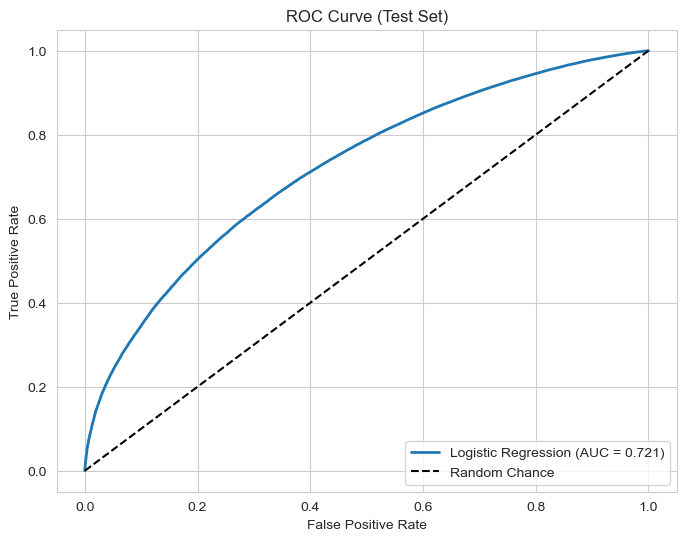

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve (Test Set)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

  ## 9. 💳 Scorecard Scaling & Validation Plot

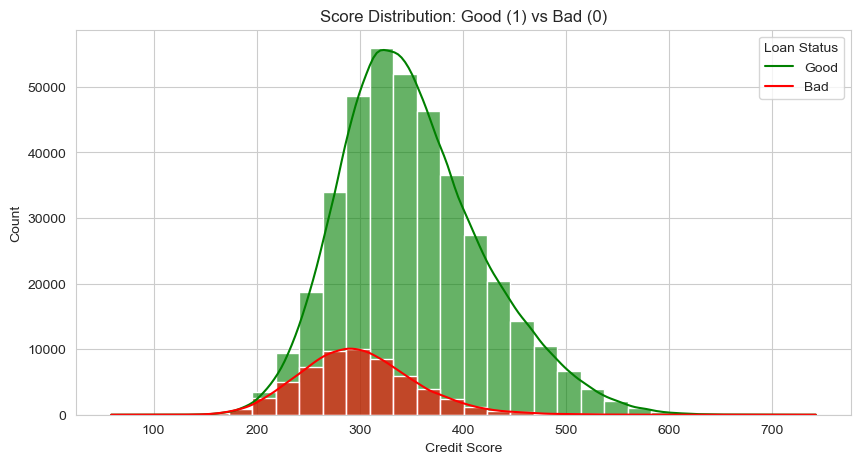

In [12]:
# Scaling Logic
PDO = 50
Base_Score = 600
Base_Odds = 50
Factor = PDO / np.log(2)
Offset = Base_Score - (Factor * np.log(Base_Odds))

# Calculate Scores (Using Raw Log-Odds)
# Scorecard points usually map to the Raw Logits. 
# The Calibration is applied to the PD% reporting, not necessarily the points ordering.
intercept = model.intercept_[0]
X_test_final['logit'] = intercept + np.dot(X_test_final[final_features], model.coef_.T)
X_test_final['score'] = Offset + (Factor * X_test_final['logit'])
X_test_final['score'] = X_test_final['score'].astype(int)

# --- ADDED VISUALIZATION: Score Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(data=X_test_final, x='score', hue=y_test, bins=30, kde=True, palette={0:'red', 1:'green'}, alpha=0.6)
plt.title('Score Distribution: Good (1) vs Bad (0)')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.legend(title='Loan Status', labels=['Good', 'Bad'])
plt.show()


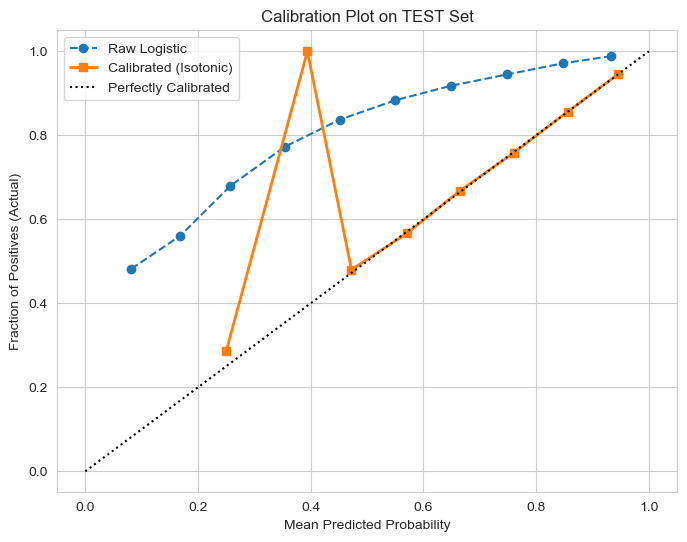

In [13]:
# Calibration Plot
prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_test_raw_proba, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_test_calib_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Raw Logistic', linestyle='--')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Calibrated (Isotonic)', linewidth=2)
plt.plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Calibration Plot on TEST Set')
plt.legend()
plt.show()

# Add Calibrated PD for Policy usage
X_test_final['calibrated_pd'] = 1 - y_test_calib_proba

In [14]:
# 1. Create a temporary DataFrame with Actuals and Calibrated Predictions
check_df = pd.DataFrame({
    'actual_target': y_test,                   # 0=Bad, 1=Good
    'calibrated_prob': y_test_calib_proba # The predictions from Isotonic
})

# 2. Create the exact same bins as the plot (0.0, 0.1, 0.2 ... 1.0)
bins = np.linspace(0, 1, 11)
check_df['bin'] = pd.cut(check_df['calibrated_prob'], bins=bins, include_lowest=True)

# 3. Group by bin and calculate stats
bin_stats = check_df.groupby('bin', observed=False).agg(
    count=('actual_target', 'count'),           # How many people in this bin?
    bad_count=('actual_target', lambda x: (1-x).sum()), # How many were actually bad?
    good_count=('actual_target', 'sum'),        # How many were actually good?
    actual_prob=('actual_target', 'mean'),      # The "Fraction of Positives" (Y-axis of plot)
    avg_pred_prob=('calibrated_prob', 'mean')   # The "Mean Predicted Probability" (X-axis of plot)
)

print(bin_stats)

spike_bin = check_df[ (check_df['calibrated_prob'] >= 0.38) & (check_df['calibrated_prob'] < 0.41) ]
print(f"Total People: {len(spike_bin)}")
print(f"Actual Outcomes:\n{spike_bin['actual_target'].value_counts()}")

                count  bad_count  good_count  actual_prob  avg_pred_prob
bin                                                                     
(-0.001, 0.1]       0        0.0         0.0          NaN            NaN
(0.1, 0.2]          0        0.0         0.0          NaN            NaN
(0.2, 0.3]          7        5.0         2.0     0.285714       0.250000
(0.3, 0.4]          1        0.0         1.0     1.000000       0.394097
(0.4, 0.5]        927      482.0       445.0     0.480043       0.472330
(0.5, 0.6]       6529     2830.0      3699.0     0.566549       0.570732
(0.6, 0.7]      23713     7888.0     15825.0     0.667355       0.664125
(0.7, 0.8]      54376    13139.0     41237.0     0.758368       0.760382
(0.8, 0.9]     165744    23759.0    141985.0     0.856652       0.856121
(0.9, 1.0]     200831    10932.0    189899.0     0.945566       0.945743
Total People: 1
Actual Outcomes:
actual_target
1.0    1
Name: count, dtype: int64


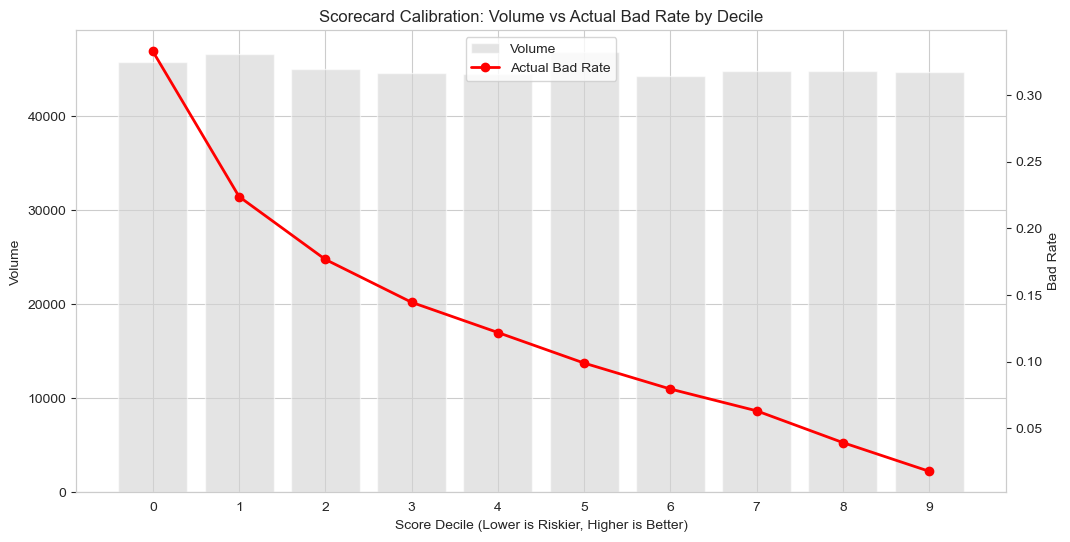

        min_score  max_score  actual_bad_rate
decile                                       
0              59        261         0.332860
1             262        286         0.223812
2             287        304         0.176668
3             305        320         0.144503
4             321        336         0.121832
5             337        354         0.098879
6             355        374         0.079407
7             375        400         0.063047
8             401        440         0.039199
9             441        742         0.017665


In [ ]:
# Create Score Bands (Deciles)
X_test_final['decile'] = pd.qcut(X_test_final['score'], 10, labels=False, duplicates='drop')

# Aggregate Data for Plotting
agg_calib = X_test_final.groupby('decile').agg(
    min_score=('score', 'min'),
    max_score=('score', 'max'),
    count=('score', 'count')
)
# Calculate Actual Bad Rate (1 - y_test because y=1 is Good)
agg_calib['actual_bad_rate'] = 1 - y_test.groupby(X_test_final['decile']).mean()

# Dual Axis Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar Chart (Volume)
ax1.bar(agg_calib.index, agg_calib['count'], color='lightgray', alpha=0.6, label='Volume')
ax1.set_xlabel('Score Decile (Lower is Riskier, Higher is Better)')
ax1.set_ylabel('Volume')
ax1.set_xticks(agg_calib.index)

# Line Chart (Bad Rate)
ax2 = ax1.twinx()
ax2.plot(agg_calib.index, agg_calib['actual_bad_rate'], color='red', marker='o', linewidth=2, label='Actual Bad Rate')
ax2.set_ylabel('Bad Rate')
ax2.grid(False)

plt.title('Scorecard Calibration: Volume vs Actual Bad Rate by Decile')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center')

plt.show()

# Print Table
print(agg_calib[['min_score', 'max_score', 'actual_bad_rate']])

In [16]:
# --- MASTER SCALE CREATION ---

# 1. Create a DataFrame with Score and Calibrated PD
final_view = X_test_final[['score', 'calibrated_pd']].copy()

# 2. Bin the scores into standard ranges (e.g., 20-point buckets)
# Adjust range(300, 850, 20) to fit your actual min/max scores
final_view['Score_Band'] = pd.cut(final_view['score'], bins=range(300, 900, 50))

# 3. Aggregate to create the Master Scale
master_scale = final_view.groupby('Score_Band', observed=False).agg(
    Average_Score=('score', 'mean'),
    Calibrated_PD=('calibrated_pd', 'mean'),
    Volume=('score', 'count')
).reset_index()

# 4. Clean up
master_scale['Calibrated_PD'] = master_scale['Calibrated_PD'].apply(lambda x: f"{x:.2%}")
master_scale['Average_Score'] = master_scale['Average_Score'].round(0)

print("\n--- FINAL SCORECARD MASTER SCALE ---")
print(master_scale)


--- FINAL SCORECARD MASTER SCALE ---
    Score_Band  Average_Score Calibrated_PD  Volume
0   (300, 350]          325.0        12.72%  136533
1   (350, 400]          373.0         7.18%   99087
2   (400, 450]          423.0         3.82%   52695
3   (450, 500]          472.0         1.91%   25266
4   (500, 550]          520.0         1.01%    9113
5   (550, 600]          568.0         0.48%    2149
6   (600, 650]          616.0         0.11%     282
7   (650, 700]          670.0         0.00%      37
8   (700, 750]          717.0         0.00%       3
9   (750, 800]            NaN          nan%       0
10  (800, 850]            NaN          nan%       0


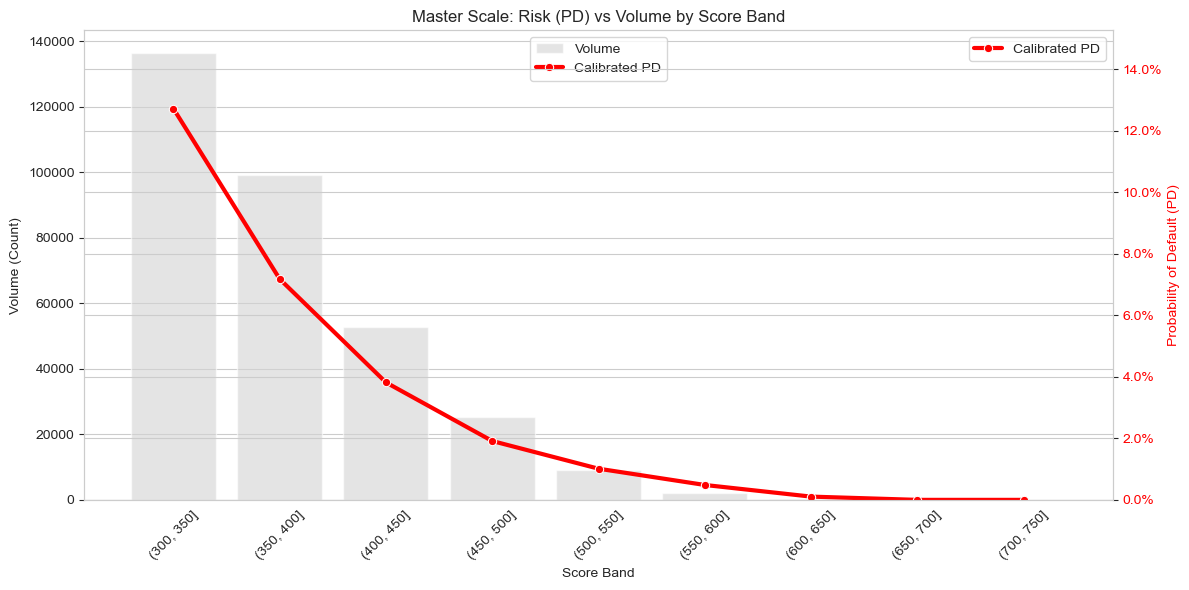


--- Master Scale Data ---
   Score_Band  Calibrated_PD  Volume
0  (300, 350]       0.127171  136533
1  (350, 400]       0.071782   99087
2  (400, 450]       0.038173   52695
3  (450, 500]       0.019131   25266
4  (500, 550]       0.010134    9113
5  (550, 600]       0.004844    2149
6  (600, 650]       0.001059     282
7  (650, 700]       0.000000      37
8  (700, 750]       0.000000       3


In [17]:
# --- VISUALIZATION: Master Scale Plot ---
import matplotlib.ticker as mtick

# 1. Prepare Data
# Re-aggregating to ensure we have numeric columns
plot_data = final_view.groupby('Score_Band', observed=False).agg(
    Calibrated_PD=('calibrated_pd', 'mean'),
    Volume=('score', 'count')
).reset_index()

# *** FIX 1: Convert Interval objects to Strings ***
plot_data['Score_Band'] = plot_data['Score_Band'].astype(str)

# *** FIX 2: Drop Empty Bins (Prevents NaN errors) ***
plot_data = plot_data[plot_data['Volume'] > 0]

# 2. Setup Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar Chart (Volume) on Left Axis
sns.barplot(data=plot_data, x='Score_Band', y='Volume', color='lightgray', alpha=0.6, ax=ax1, label='Volume')
ax1.set_xlabel('Score Band')
ax1.set_ylabel('Volume (Count)')
ax1.tick_params(axis='x', rotation=45)

# Line Chart (PD) on Right Axis
ax2 = ax1.twinx()
sns.lineplot(data=plot_data, x='Score_Band', y='Calibrated_PD', color='red', marker='o', linewidth=3, ax=ax2, label='Calibrated PD')
ax2.set_ylabel('Probability of Default (PD)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# *** FIX 3: Safe Y-Limit Calculation ***
# Calculate top limit only if data exists, otherwise default to 1.0
top_limit = plot_data['Calibrated_PD'].max()
if pd.isna(top_limit) or top_limit == 0:
    top_limit = 1.0
else:
    top_limit *= 1.2

ax2.set_ylim(0, top_limit) 

# Format Y-axis as Percentage
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Title & Legend
plt.title('Master Scale: Risk (PD) vs Volume by Score Band')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center')

plt.tight_layout()
plt.show()

# Print Table for Inspection
print("\n--- Master Scale Data ---")
print(plot_data)